# Customer Intelligence System
### End-to-End Country Segmentation using EDA, K-Means, DBSCAN, Random Forest and XGBoost

## 1. Import Libraries

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix






## 2. Load Dataset

In [6]:

df = pd.read_csv('Country-data.csv')
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Dataset Overview

In [7]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

df.info()


Shape: (167, 10)

Columns:
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='str')

Data Types:
country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null   

## 4. Missing Values and Duplicate Check

In [8]:

print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows: 0


## 5. Statistical Summary

In [9]:

df.describe()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## 6. EDA - Histograms

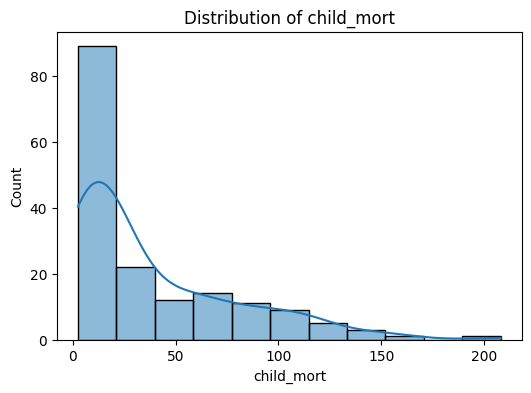

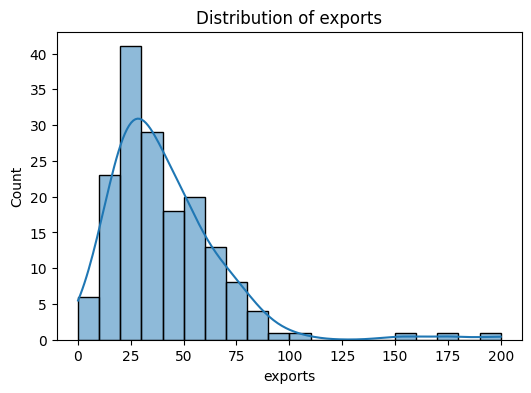

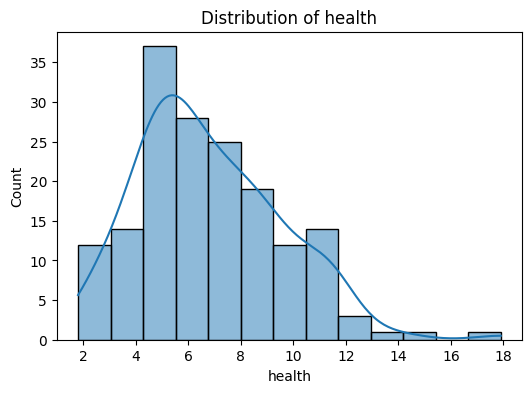

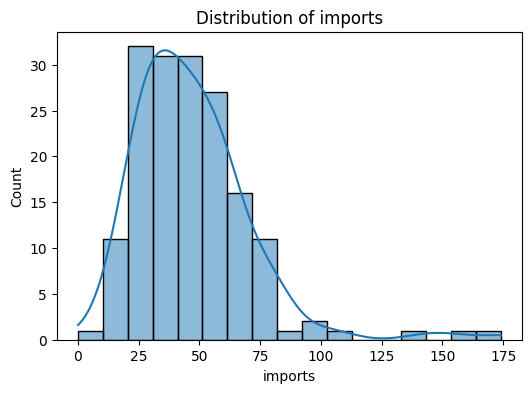

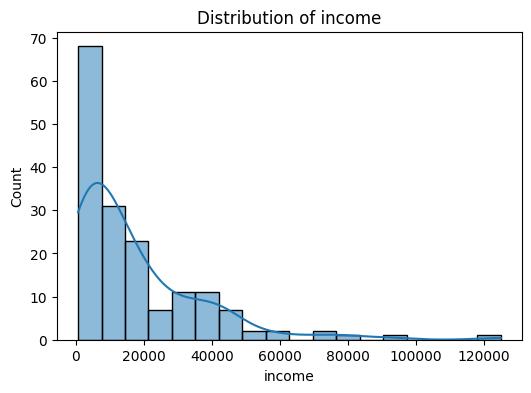

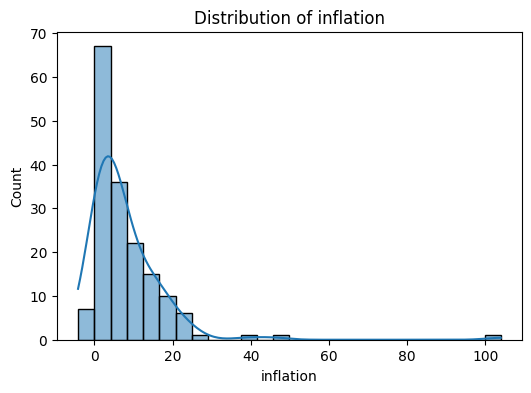

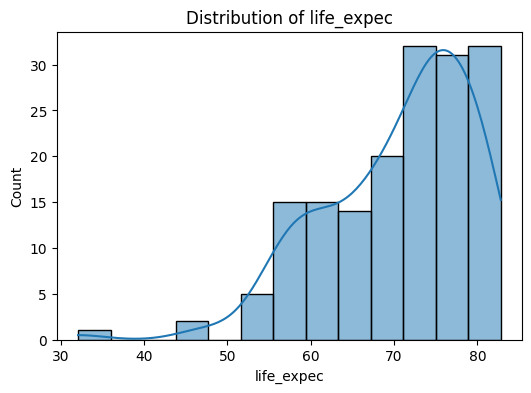

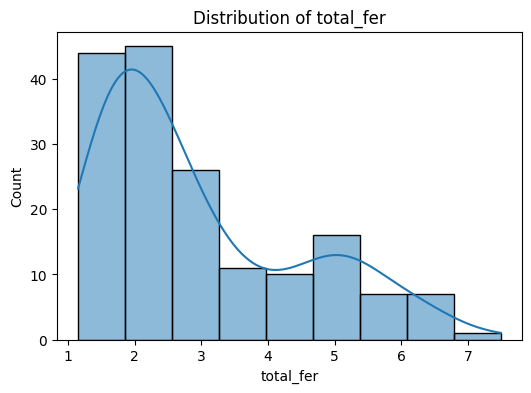

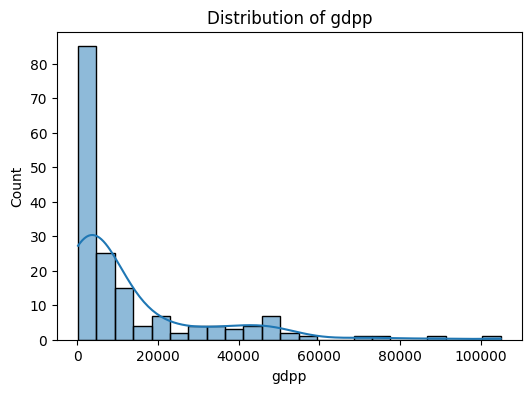

In [10]:

num_cols = df.drop('country', axis=1).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


## 7. Outlier Detection using Boxplots

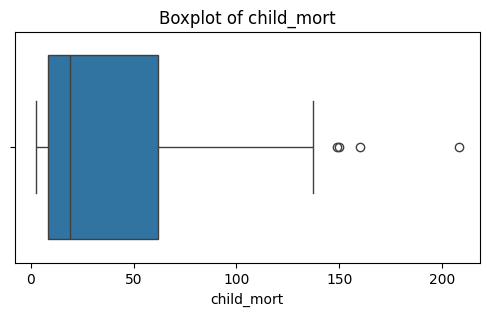

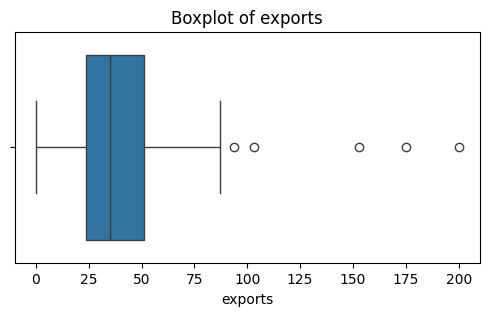

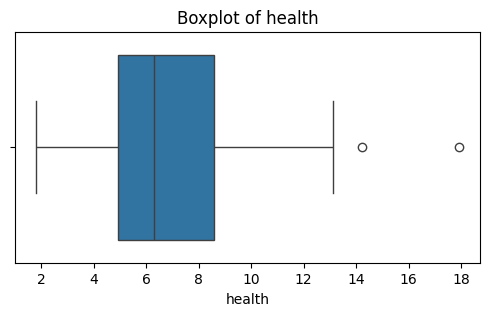

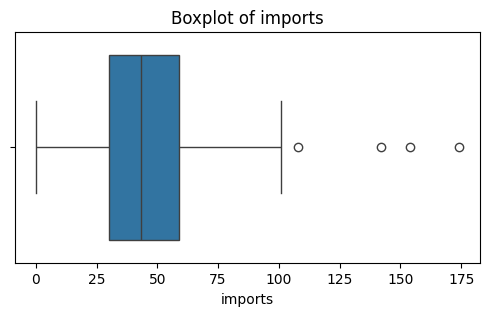

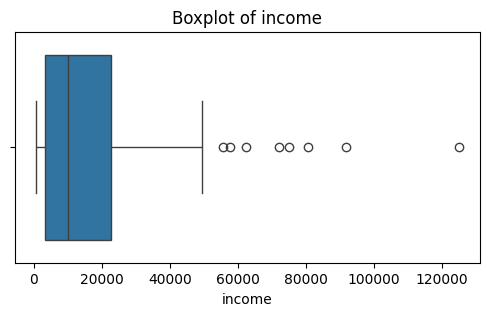

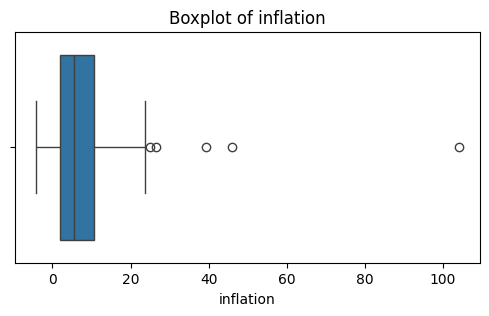

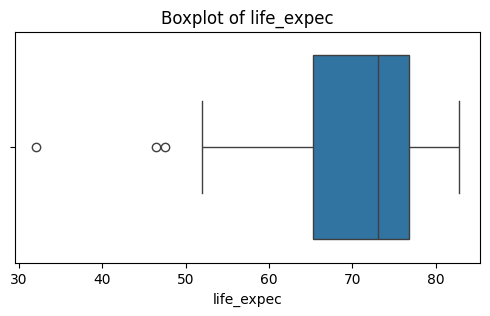

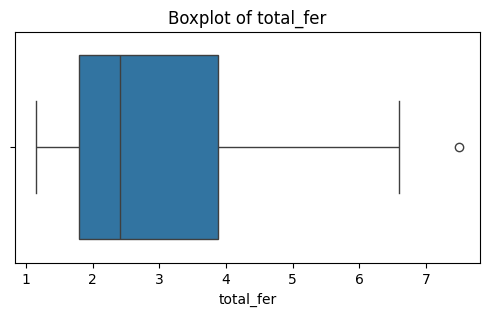

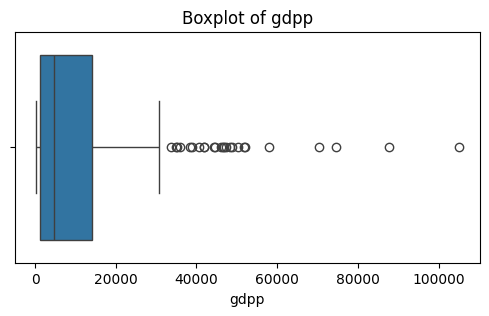

In [11]:

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


## 8. Correlation Heatmap

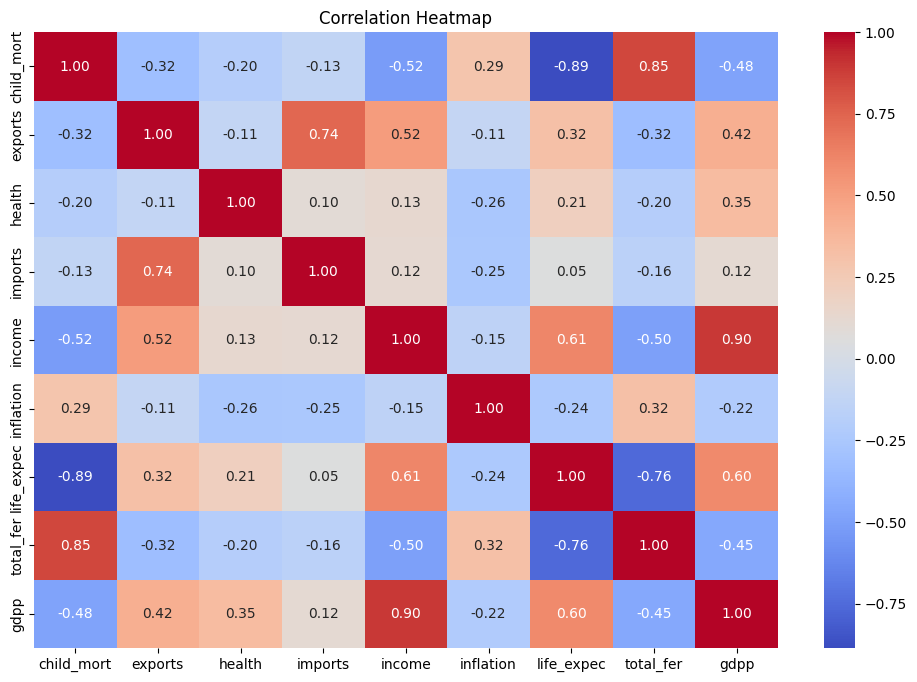

In [12]:

corr = df.drop('country', axis=1).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


## 9. Scatter Plot Analysis

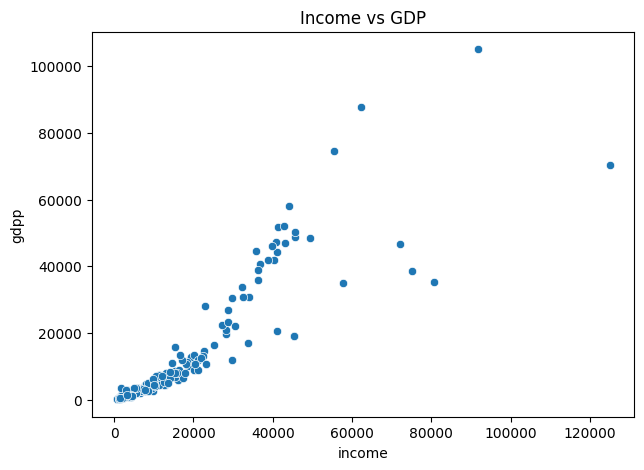

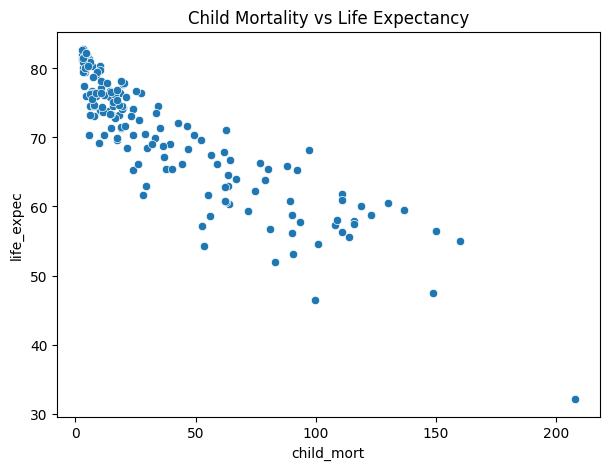

In [13]:

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='income', y='gdpp')
plt.title('Income vs GDP')
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='child_mort', y='life_expec')
plt.title('Child Mortality vs Life Expectancy')
plt.show()


## 10. Data Preprocessing

In [14]:

country_names = df['country']

X = df.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)


(167, 9)


## 11. Elbow Method

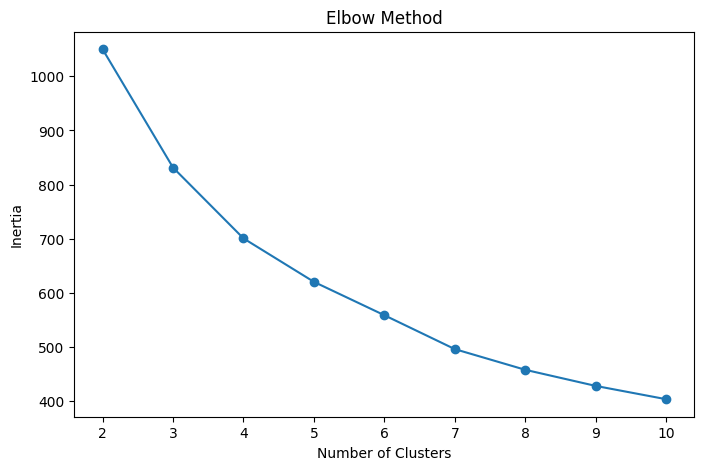

In [15]:

inertia = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


## 12. K-Means Clustering

In [16]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'].value_counts())
print('Silhouette Score:', silhouette_score(X_scaled, df['Cluster']))


Cluster
2    84
1    47
0    36
Name: count, dtype: int64
Silhouette Score: 0.28329575683463126


## 13. Cluster Profiling

In [17]:

cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
cluster_profile


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


## 14. DBSCAN Clustering

In [18]:

dbscan = DBSCAN(eps=1.5, min_samples=5)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print(df['DBSCAN_Cluster'].value_counts())


DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


## 15. PCA Visualization

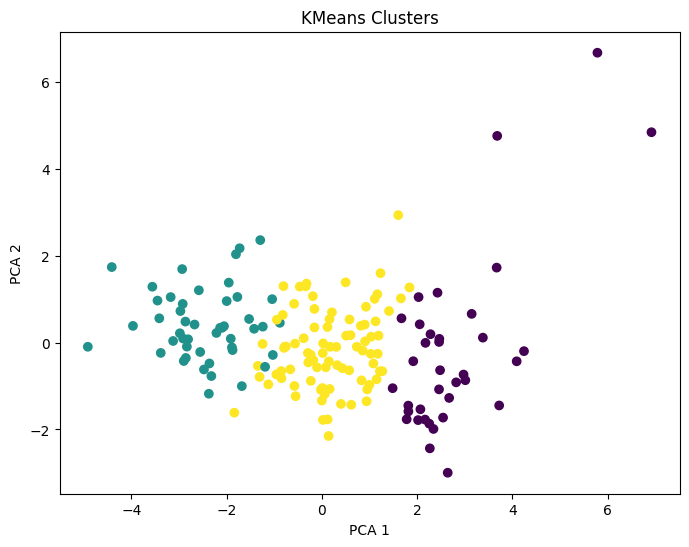

In [19]:

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('KMeans Clusters')
plt.show()


## 16. Random Forest Classification

In [20]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    df['Cluster'],
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



## 17. Feature Importance

      Feature  Importance
0  child_mort    0.279315
8        gdpp    0.196765
4      income    0.155490
6  life_expec    0.151215
7   total_fer    0.149904
2      health    0.032411
5   inflation    0.014174
1     exports    0.013982
3     imports    0.006743


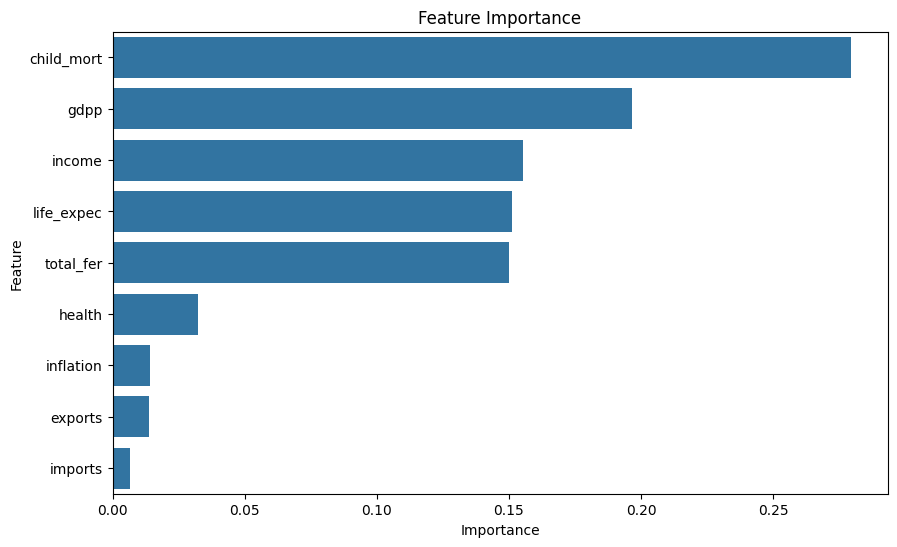

In [22]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.show()
